In [2]:
import pyspark.sql.functions as fn

In [212]:

customers.printSchema()
orders.printSchema()
order_items.printSchema()
products.printSchema()
categories.printSchema()
brands.printSchema()
stores.printSchema()
staffs.printSchema()
stocks.printSchema()


root
 |-- customer_id: integer (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- phone: string (nullable = false)
 |-- email: string (nullable = false)
 |-- street: string (nullable = false)
 |-- city: string (nullable = false)
 |-- state: string (nullable = false)
 |-- zip_code: string (nullable = false)
 |-- full_name: string (nullable = false)

root
 |-- order_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- order_status: integer (nullable = false)
 |-- order_date: date (nullable = true)
 |-- required_date: date (nullable = true)
 |-- shipped_date: date (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- staff_id: integer (nullable = true)

root
 |-- order_id: integer (nullable = true)
 |-- item_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = false)
 |-- list_price: double (nullable = false)
 |-- discount: double (nullable = fa

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CSV Processing") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/22 06:24:39 WARN Utils: Your hostname, DESKTOP-IL3FF3T, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/22 06:24:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 06:24:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## load Data

In [5]:


# customers = spark.read.option("header", True).option("inferSchema", True).csv("customers.csv")
# products  = spark.read.option("header", True).option("inferSchema", True).csv("products.csv")
# orders    = spark.read.option("header", True).option("inferSchema", True).csv("order_items.csv")
# categories= spark.read.option("header", True).option("inferSchema", True).csv("categories.csv")
# stores    = spark.read.option("header", True).option("inferSchema", True).csv("stores.csv")
# staffs    = spark.read.option("header", True).option("inferSchema", True).csv("staffs.csv")
# stocks    = spark.read.option("header", True).option("inferSchema", True).csv("stocks.csv")


## EDA

#### Customers 

In [6]:
customers = spark.read.option("header", True).option("inferSchema", True).csv("customers.csv")

In [7]:
# structure of data
customers.printSchema()

root
 |-- customer_id: integer (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip_code: integer (nullable = true)



In [8]:
customers = customers \
    .withColumn("customer_id", fn.col("customer_id").cast("int")) \
    .withColumn("first_name", fn.col("first_name").cast("string")) \
    .withColumn("last_name", fn.col("last_name").cast("string")) \
    .withColumn("phone", fn.col("phone").cast("string")) \
    .withColumn("email", fn.col("email").cast("string")) \
    .withColumn("street", fn.col("street").cast("string")) \
    .withColumn("city", fn.col("city").cast("string")) \
    .withColumn("state", fn.col("state").cast("string")) \
    .withColumn("zip_code", fn.col("zip_code").cast("string"))

In [9]:
# Preview data
customers.show(5)


+-----------+----------+---------+--------------+--------------------+--------------------+-------------+-----+--------+
|customer_id|first_name|last_name|         phone|               email|              street|         city|state|zip_code|
+-----------+----------+---------+--------------+--------------------+--------------------+-------------+-----+--------+
|          1|     Debra|    Burks|          NULL|debra.burks@yahoo...|   9273 Thorne Ave. | Orchard Park|   NY|   14127|
|          2|     Kasha|     Todd|          NULL|kasha.todd@yahoo.com|    910 Vine Street |     Campbell|   CA|   95008|
|          3|    Tameka|   Fisher|          NULL|tameka.fisher@aol...|769C Honey Creek ...|Redondo Beach|   CA|   90278|
|          4|     Daryl|   Spence|          NULL|daryl.spence@aol.com|     988 Pearl Lane |    Uniondale|   NY|   11553|
|          5|Charolette|     Rice|(916) 381-6003|charolette.rice@m...|      107 River Dr. |   Sacramento|   CA|   95820|
+-----------+----------+--------

In [10]:
# Count rows
customers.count()


1445

In [11]:
customers.describe()


DataFrame[summary: string, customer_id: string, first_name: string, last_name: string, phone: string, email: string, street: string, city: string, state: string, zip_code: string]

In [12]:
# Describe (statistics)
customers.describe().show()


26/04/22 06:25:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+----------+---------+--------------+--------------------+-------------------+---------+-----+------------------+
|summary|       customer_id|first_name|last_name|         phone|               email|             street|     city|state|          zip_code|
+-------+------------------+----------+---------+--------------+--------------------+-------------------+---------+-----+------------------+
|  count|              1445|      1445|     1445|          1445|                1445|               1445|     1445| 1445|              1445|
|   mean|             723.0|      NULL|     NULL|          NULL|                NULL|               NULL|     NULL| NULL| 34200.01522491349|
| stddev|417.27988209354163|      NULL|     NULL|          NULL|                NULL|               NULL|     NULL| NULL|34733.933550915826|
|    min|                 1|     Aaron|  Acevedo|(210) 436-8676|aaron.knapp@yahoo...|1 Arrowhead Street |   Albany|   CA|             10002|
|    max|    

In [13]:
# check null values 
customers.select([
    
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in customers.columns 
]).show()


+-----------+----------+---------+-----+-----+------+----+-----+--------+
|customer_id|first_name|last_name|phone|email|street|city|state|zip_code|
+-----------+----------+---------+-----+-----+------+----+-----+--------+
|          0|         0|        0|    0|    0|     0|   0|    0|       0|
+-----------+----------+---------+-----+-----+------+----+-----+--------+



In [14]:
# make sure no nulls in data 
customers = customers.fillna({
    "phone": "Unknown",
    "email": "Unknown",
    "street": "Unknown" ,
    "city": "Unknown" ,
    "state": "Unknown" ,
    "zip_code": "Unknown"
    
})


In [15]:
# remove duplicates 
customers = customers.dropDuplicates() 

In [16]:
# create full name 
customers = customers.withColumn(
    "full_name",
    fn.initcap(
         fn.concat_ws(
            " ",
            fn.trim(fn.col("first_name")),
            fn.trim(fn.col("last_name"))
        )
    )
)

#customers = customers.withColumn(
#    "full_name",
#    fn.initcap(fn.col("full_name"))
#)

In [17]:
# Standardize city, and state
customers = customers.withColumn(
    "city", fn.upper(fn.trim(fn.col("city")) )
).withColumn(
    "state", fn.upper(fn.trim(fn.col("state")))

).withColumn(
    "street", fn.upper(fn.trim(fn.col("street")))

)


In [18]:
# Customers per state 
print("================Customers per state================")
customers.groupBy("state").count().orderBy("count", ascending=False).show()

================Customers per state================


[Stage 14:>                                                         (0 + 1) / 1]

+-----+-----+
|state|count|
+-----+-----+
|   NY| 1019|
|   CA|  284|
|   TX|  142|
+-----+-----+



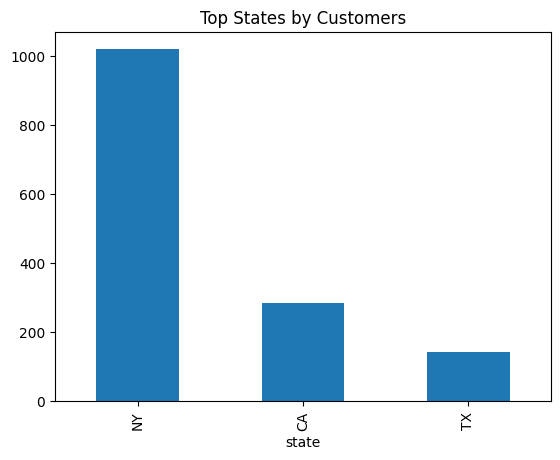

In [19]:
import matplotlib.pyplot as plt 

pdf = customers.toPandas() 
pdf["state"].value_counts().plot(kind='bar')
plt.title("Top States by Customers")
plt.show()

In [20]:
# Customers per city
print("================Customers per city================")
customers.groupBy("city").count().orderBy("count", ascending=False).show()


================Customers per city================
+--------------+-----+
|          city|count|
+--------------+-----+
|  MOUNT VERNON|   20|
|     SCARSDALE|   17|
|  BALLSTON SPA|   17|
|   CANANDAIGUA|   14|
|   FLORAL PARK|   13|
|      LONGVIEW|   13|
|      OSSINING|   13|
|       WEBSTER|   12|
|    SAN ANGELO|   12|
|    RONKONKOMA|   12|
|       MERRICK|   12|
|     SMITHTOWN|   12|
|       ASTORIA|   12|
|  HOWARD BEACH|   12|
|     SUNNYSIDE|   12|
| RICHMOND HILL|   12|
|CANYON COUNTRY|   12|
|  ORCHARD PARK|   11|
|       ANAHEIM|   11|
|SOUTH EL MONTE|   11|
+--------------+-----+
only showing top 20 rows


In [21]:
# Top cities
print("================top 10 cities by cutomers================")
customers.groupBy("city").count().orderBy(fn.col("count").desc()).show(10)

================top 10 cities by cutomers================
+------------+-----+
|        city|count|
+------------+-----+
|MOUNT VERNON|   20|
|BALLSTON SPA|   17|
|   SCARSDALE|   17|
| CANANDAIGUA|   14|
| FLORAL PARK|   13|
|    LONGVIEW|   13|
|    OSSINING|   13|
|  RONKONKOMA|   12|
|  SAN ANGELO|   12|
|     WEBSTER|   12|
+------------+-----+
only showing top 10 rows


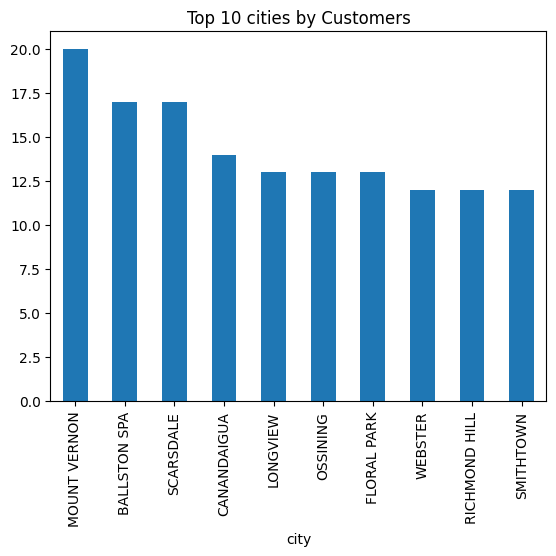

In [22]:
pdf["city"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 cities by Customers")
plt.show()

# Products

In [23]:
products  = spark.read.option("header", True).option("inferSchema", True).csv("products.csv")

In [24]:
products.printSchema()


root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- brand_id: integer (nullable = true)
 |-- category_id: integer (nullable = true)
 |-- model_year: integer (nullable = true)
 |-- list_price: double (nullable = true)



In [25]:
products.show(5)


+----------+--------------------+--------+-----------+----------+----------+
|product_id|        product_name|brand_id|category_id|model_year|list_price|
+----------+--------------------+--------+-----------+----------+----------+
|         1|     Trek 820 - 2016|       9|          6|      2016|    379.99|
|         2|Ritchey Timberwol...|       5|          6|      2016|    749.99|
|         3|Surly Wednesday F...|       8|          6|      2016|    999.99|
|         4|Trek Fuel EX 8 29...|       9|          6|      2016|   2899.99|
|         5|Heller Shagamaw F...|       3|          6|      2016|   1320.99|
+----------+--------------------+--------+-----------+----------+----------+
only showing top 5 rows


In [26]:
products = products \
    .withColumn("product_id", fn.col("product_id").cast("int")) \
    .withColumn("product_name", fn.col("product_name").cast("string")) \
    .withColumn("brand_id", fn.col("brand_id").cast("int")) \
    .withColumn("category_id", fn.col("category_id").cast("int")) \
    .withColumn("model_year", fn.col("model_year").cast("int")) \
    .withColumn("list_price", fn.col("list_price").cast("double"))


In [27]:
products.select([
    
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in products.columns 
]).show()


+----------+------------+--------+-----------+----------+----------+
|product_id|product_name|brand_id|category_id|model_year|list_price|
+----------+------------+--------+-----------+----------+----------+
|         0|           0|       0|          0|         0|         0|
+----------+------------+--------+-----------+----------+----------+



In [28]:
products = products.fillna({
    "product_name": "Unknown",
    "model_year": 0 ,
    "list_price": 0.0,
    
})

In [29]:
# Standardizing text 
products = products.withColumn(
    "product_name",
    fn.initcap(
        fn.regexp_replace(
            fn.trim(fn.coalesce(fn.col("product_name"), fn.lit(""))),
            " +", " "
        )
    )
)


In [30]:
products.count()


321

In [31]:
products.describe().show()


+-------+-----------------+--------------------+------------------+-----------------+------------------+------------------+
|summary|       product_id|        product_name|          brand_id|      category_id|        model_year|        list_price|
+-------+-----------------+--------------------+------------------+-----------------+------------------+------------------+
|  count|              321|                 321|               321|              321|               321|               321|
|   mean|            161.0|                NULL|5.4766355140186915| 4.02803738317757|2017.5919003115264|1520.5914018691537|
| stddev|92.80894353455382|                NULL| 3.708130748080468|2.188569498233523|0.6650632977626271|1612.1527653545168|
|    min|                1|"electra Girl's H...|                 1|                1|              2016|             89.99|
|    max|              321|Trek Xm700+ Lowst...|                 9|                7|              2019|          11999.99|
+-------

In [32]:
print("==================Distinct categories==================")
products.select("category_id").distinct().show()

==================Distinct categories==================
+-----------+
|category_id|
+-----------+
|          1|
|          6|
|          3|
|          5|
|          4|
|          7|
|          2|
+-----------+



In [33]:
print("==================Distinct brandies==================")
products.select("brand_id").distinct().show()

==================Distinct brandies==================
+--------+
|brand_id|
+--------+
|       1|
|       6|
|       3|
|       5|
|       9|
|       4|
|       8|
|       7|
|       2|
+--------+



In [34]:
# check nulls
products.select([
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in products.columns
]).show()

+----------+------------+--------+-----------+----------+----------+
|product_id|product_name|brand_id|category_id|model_year|list_price|
+----------+------------+--------+-----------+----------+----------+
|         0|           0|       0|          0|         0|         0|
+----------+------------+--------+-----------+----------+----------+



In [35]:
# remove duplicates
products = products.dropDuplicates()


In [36]:
# feature engineering
products = products.withColumn(
    "price_category",
    fn.when(fn.col("list_price") < 300, "LOW")
      .when(fn.col("list_price") < 1000, "MEDIUM")
      .otherwise("HIGH")
)

In [37]:
pdf = products.toPandas()

In [38]:
print("=====================Products per Category=====================")
products.groupBy("category_id") \
    .count() \
    .orderBy(fn.col("count").desc()) \
    .show()



=====================Products per Category=====================
+-----------+-----+
|category_id|count|
+-----------+-----+
|          3|   78|
|          6|   60|
|          7|   60|
|          1|   59|
|          2|   30|
|          5|   24|
|          4|   10|
+-----------+-----+



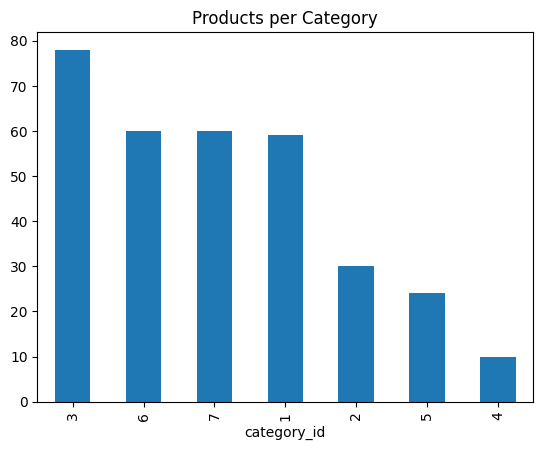

In [39]:
pdf['category_id'].value_counts().plot(kind='bar')
plt.title("Products per Category")
plt.show()

In [40]:
print("=====================Products per brand=====================")
products.groupBy("brand_id") \
    .count() \
    .orderBy(fn.col("count").desc()) \
    .show()



=====================Products per brand=====================
+--------+-----+
|brand_id|count|
+--------+-----+
|       9|  135|
|       1|  118|
|       8|   25|
|       7|   23|
|       2|   10|
|       6|    3|
|       3|    3|
|       4|    3|
|       5|    1|
+--------+-----+



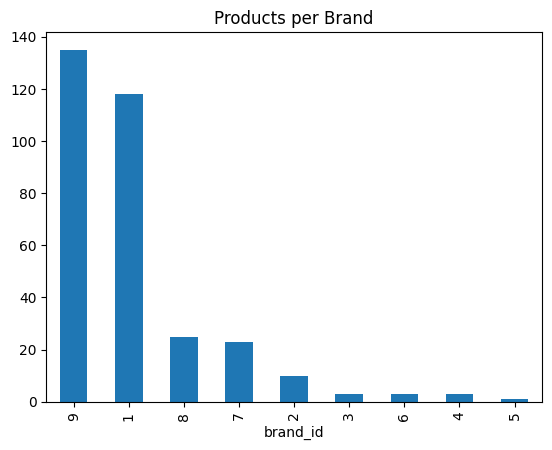

In [41]:
pdf['brand_id'].value_counts().plot(kind='bar')
plt.title("Products per Brand")
plt.show()

In [42]:
print("=====================Average Price per Category=====================")
products.groupBy("category_id") \
    .avg("list_price") \
    .show()



=====================Average Price per Category=====================
+-----------+------------------+
|category_id|   avg(list_price)|
+-----------+------------------+
|          1| 287.7866101694914|
|          6|1649.7573333333348|
|          3| 730.4123076923072|
|          5|3281.6566666666663|
|          4|          2542.793|
|          7|3175.3573333333325|
|          2| 682.1233333333334|
+-----------+------------------+



In [43]:
print("=====================Price Distribution=====================")
products.groupBy("price_category").count().orderBy(fn.col("count").desc()).show()


=====================Price Distribution=====================
+--------------+-----+
|price_category|count|
+--------------+-----+
|        MEDIUM|  153|
|          HIGH|  126|
|           LOW|   42|
+--------------+-----+



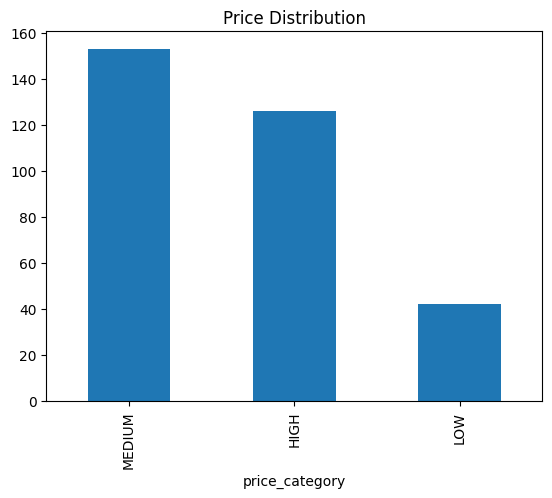

In [44]:
pdf['price_category'].value_counts().plot(kind='bar')
plt.title("Price Distribution")
plt.show()

In [45]:
print("=====================Most Expensive Products=====================")
products.orderBy(fn.col("list_price").desc()).show(10)


=====================Most Expensive Products=====================
+----------+--------------------+--------+-----------+----------+----------+--------------+
|product_id|        product_name|brand_id|category_id|model_year|list_price|price_category|
+----------+--------------------+--------+-----------+----------+----------+--------------+
|       155|Trek Domane Slr 9...|       9|          7|      2018|  11999.99|          HIGH|
|       149|Trek Domane Slr 8...|       9|          7|      2018|   7499.99|          HIGH|
|       169|Trek Emonda Slr 8...|       9|          7|      2018|   6499.99|          HIGH|
|        51|Trek Silque Slr 8...|       9|          7|      2017|   6499.99|          HIGH|
|       157|Trek Domane Sl Fr...|       9|          7|      2018|   6499.99|          HIGH|
|       156|Trek Domane Sl Fr...|       9|          7|      2018|   6499.99|          HIGH|
|        50|Trek Silque Slr 7...|       9|          7|      2017|   5999.99|          HIGH|
|       148|Tr

In [46]:
print("=====================Cheapest Products=====================")
products.orderBy(fn.col("list_price")).show(10)

=====================Cheapest Products=====================
+----------+--------------------+--------+-----------+----------+----------+--------------+
|product_id|        product_name|brand_id|category_id|model_year|list_price|price_category|
+----------+--------------------+--------+-----------+----------+----------+--------------+
|       263|Strider Classic 1...|       6|          1|      2018|     89.99|           LOW|
|        84|Sun Bicycles Lil ...|       7|          1|      2017|    109.99|           LOW|
|        83|Trek Boy's Kickst...|       9|          1|      2017|    149.99|           LOW|
|        86|Trek Girl's Kicks...|       9|          1|      2017|    149.99|           LOW|
|       268|Trek Kickster - 2018|       9|          1|      2018|    159.99|           LOW|
|        88|Trek Precaliber 1...|       9|          1|      2017|    189.99|           LOW|
|        87|Trek Precaliber 1...|       9|          1|      2017|    189.99|           LOW|
|       267|Trek Pre

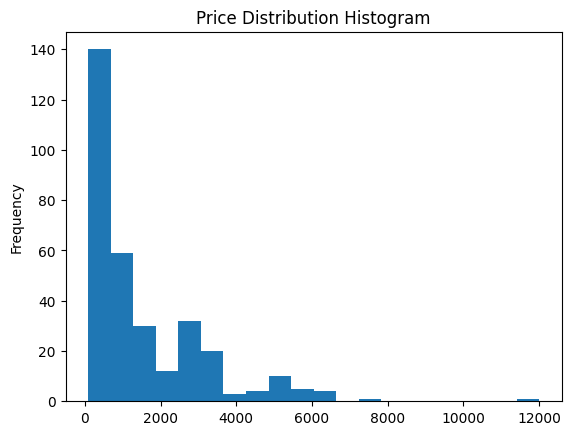

In [47]:
pdf['list_price'].plot(kind='hist', bins=20)
plt.title("Price Distribution Histogram")
plt.show()


## Orders

In [103]:
orders    = spark.read.option("header", True).csv("orders.csv")

In [104]:
orders.printSchema()


root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- required_date: string (nullable = true)
 |-- shipped_date: string (nullable = true)
 |-- store_id: string (nullable = true)
 |-- staff_id: string (nullable = true)



In [105]:
orders.show(5)

+--------+-----------+------------+----------+-------------+------------+--------+--------+
|order_id|customer_id|order_status|order_date|required_date|shipped_date|store_id|staff_id|
+--------+-----------+------------+----------+-------------+------------+--------+--------+
|       1|        259|           4|2016-01-01|   2016-01-03|  2016-01-03|       1|       2|
|       2|       1212|           4|2016-01-01|   2016-01-04|  2016-01-03|       2|       6|
|       3|        523|           4|2016-01-02|   2016-01-05|  2016-01-03|       2|       7|
|       4|        175|           4|2016-01-03|   2016-01-04|  2016-01-05|       1|       3|
|       5|       1324|           4|2016-01-03|   2016-01-06|  2016-01-06|       2|       6|
+--------+-----------+------------+----------+-------------+------------+--------+--------+
only showing top 5 rows


In [106]:
# orders = orders.withColumn(
#     "shipped_date",
#     fn.expr("try_cast(nullif(shipped_date, 'NULL') as date)")
# )


In [107]:
def clean_date(col_name):
    return fn.to_date(
        fn.when(fn.col(col_name).isin("NULL", "null", ""), None)
          .otherwise(fn.col(col_name)),
        "yyyy-MM-dd"
    )


In [108]:
# orders = orders \
#     .withColumn("order_date", clean_date("order_date")) \
#     .withColumn("required_date", clean_date("required_date")) \
#     .withColumn("shipped_date", clean_date("shipped_date")) \
#     .withColumn("order_id", fn.col("order_id").cast("int")) \
#     .withColumn("customer_id", fn.col("customer_id").cast("int")) \
#     .withColumn("order_status", fn.col("order_status").cast("int")) \
#     .withColumn("store_id", fn.col("store_id").cast("int")) \
#     .withColumn("staff_id", fn.col("staff_id").cast("int"))


In [109]:
orders.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- order_status: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- required_date: date (nullable = true)
 |-- shipped_date: date (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- staff_id: integer (nullable = true)



In [110]:
orders.show(5)


+--------+-----------+------------+----------+-------------+------------+--------+--------+
|order_id|customer_id|order_status|order_date|required_date|shipped_date|store_id|staff_id|
+--------+-----------+------------+----------+-------------+------------+--------+--------+
|       1|        259|           4|2016-01-01|   2016-01-03|  2016-01-03|       1|       2|
|       2|       1212|           4|2016-01-01|   2016-01-04|  2016-01-03|       2|       6|
|       3|        523|           4|2016-01-02|   2016-01-05|  2016-01-03|       2|       7|
|       4|        175|           4|2016-01-03|   2016-01-04|  2016-01-05|       1|       3|
|       5|       1324|           4|2016-01-03|   2016-01-06|  2016-01-06|       2|       6|
+--------+-----------+------------+----------+-------------+------------+--------+--------+
only showing top 5 rows


In [111]:
orders.count()


1615

In [112]:
orders.describe().show()


+-------+-----------------+-----------------+------------------+------------------+------------------+
|summary|         order_id|      customer_id|      order_status|          store_id|          staff_id|
+-------+-----------------+-----------------+------------------+------------------+------------------+
|  count|             1615|             1615|              1615|              1615|              1615|
|   mean|            808.0|654.1715170278637| 3.778947368421053|1.8922600619195047| 5.855108359133127|
| stddev|466.3546576015583|443.2299672822404|0.6934300510981584|0.5583950108014721|1.9138987107775463|
|    min|                1|                1|                 1|                 1|                 2|
|    max|             1615|             1445|                 4|                 3|                 9|
+-------+-----------------+-----------------+------------------+------------------+------------------+



In [113]:
orders.select("order_id").distinct().count()


1615

In [114]:
orders = orders.filter(
    fn.col("order_id").isNotNull() &
    fn.col("store_id").isNotNull() &
    fn.col("staff_id").isNotNull()&
    fn.col("customer_id").isNotNull()
)


In [115]:
orders.select([
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in orders.columns
]).show()

+--------+-----------+------------+----------+-------------+------------+--------+--------+
|order_id|customer_id|order_status|order_date|required_date|shipped_date|store_id|staff_id|
+--------+-----------+------------+----------+-------------+------------+--------+--------+
|       0|          0|           0|         0|            0|         170|       0|       0|
+--------+-----------+------------+----------+-------------+------------+--------+--------+



In [116]:
orders = orders.fillna({
    "order_status": -1,
    
})


In [117]:
orders = orders.dropDuplicates()


## Order items

In [126]:
order_items    = spark.read.option("header", True).option("inferSchema", True).csv("order_items.csv")

In [127]:
order_items.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- item_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- list_price: double (nullable = true)
 |-- discount: double (nullable = true)



In [128]:
order_items = order_items.filter(
    fn.col("order_id").isNotNull() &
    fn.col("item_id").isNotNull() &
    fn.col("product_id").isNotNull()
)

In [129]:
order_items = order_items \
    .withColumn("order_id", fn.col("order_id").cast("int")) \
    .withColumn("item_id", fn.col("item_id").cast("int")) \
    .withColumn("product_id", fn.col("product_id").cast("int")) \
    .withColumn("quantity", fn.col("quantity").cast("int")) \
    .withColumn("list_price", fn.col("list_price").cast("double")) \
    .withColumn("discount", fn.col("discount").cast("double"))

In [130]:
order_items = order_items.fillna({
    "quantity": 1,
    "list_price": 0.0,
    "discount": 0.0
})


In [131]:
order_items = order_items.dropDuplicates()


In [133]:
# feature engineering 
# transformations
order_items = order_items.withColumn(
    "total_price",
    fn.col("quantity") * fn.col("list_price") * (1-fn.col("discount"))
)

In [134]:
order_items.selectExpr("sum(total_price) as total_revenue").show()

+-----------------+
|    total_revenue|
+-----------------+
|7689116.557599988|
+-----------------+



In [135]:
print("============Revenue per order============")
order_items.groupBy("order_id")\
    .sum("total_price")\
    .withColumnRenamed("sum(total_price)","order_total")\
    .show()

============Revenue per order============
+--------+------------------+
|order_id|       order_total|
+--------+------------------+
|     148|          256.4905|
|     833|          1139.981|
|     471|           728.973|
|    1088|3110.8567000000003|
|    1591|6357.9223999999995|
|    1342|1681.4809999999998|
|     496| 914.9670000000001|
|    1580|1114.1653999999999|
|    1238|          5528.957|
|     463|          502.1814|
|     858|         4094.8481|
|     897|           839.781|
|     243| 9385.101999999999|
|     737|         3531.3039|
|    1084|         4410.3574|
|    1507| 7447.328399999999|
|     623|1673.9906999999998|
|    1460|        14566.4345|
|    1483|1730.2718999999997|
|    1522|         3125.0724|
+--------+------------------+
only showing top 20 rows


In [136]:
print("============Top 10 orders============")
order_items.groupBy("order_id")\
    .sum("total_price")\
    .orderBy(fn.col("sum(total_price)").desc())\
    .show(10)

============Top 10 orders============
+--------+------------------+
|order_id|  sum(total_price)|
+--------+------------------+
|    1541|        29147.0264|
|     937|27050.718199999996|
|    1506|        25574.9555|
|    1482|        25365.4344|
|    1364|        24890.6244|
|     930|24607.026100000003|
|    1348|        20648.9537|
|    1334|        20509.4254|
|     973|        20177.7457|
|    1118|        19329.9492|
+--------+------------------+
only showing top 10 rows


In [137]:
pdf = order_items.toPandas()


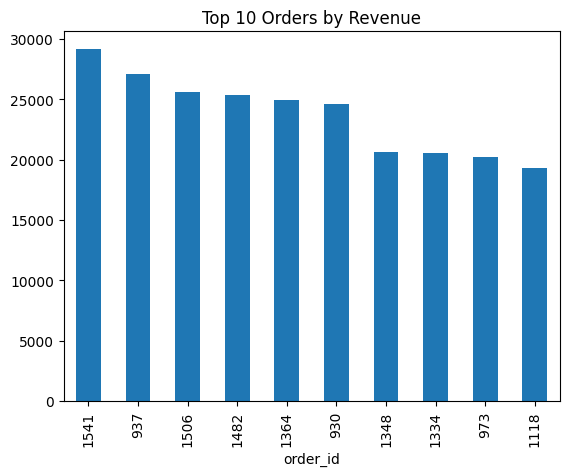

In [138]:
top_orders = pdf.groupby("order_id")["total_price"].sum().sort_values(ascending=False).head(10)

top_orders.plot(kind='bar')
plt.title("Top 10 Orders by Revenue")
plt.show()

In [139]:
print("============Most sold products============")
order_items.groupBy("order_id")\
    .sum("quantity")\
    .orderBy(fn.col("sum(quantity)").desc())\
    .show(10)

============Most sold products============
+--------+-------------+
|order_id|sum(quantity)|
+--------+-------------+
|     944|           10|
|     813|           10|
|     100|           10|
|     518|           10|
|    1577|           10|
|    1124|            9|
|     906|            9|
|    1055|            9|
|    1516|            9|
|     806|            9|
+--------+-------------+
only showing top 10 rows


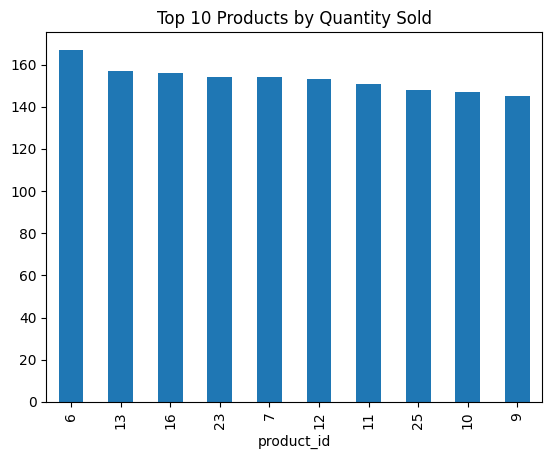

In [140]:
top_products = pdf.groupby("product_id")["quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.show()


In [142]:
print("============Average Order Value============")
order_items.groupBy("order_id")\
    .sum("total_price")\
    .agg({"sum(total_price)": "avg"})\
    .show()

============Average Order Value============
+---------------------+
|avg(sum(total_price))|
+---------------------+
|    4761.062883962851|
+---------------------+



## Brands

In [145]:
brands= spark.read.option("header", True).option("inferSchema", True).csv("brands.csv")

In [146]:
brands.printSchema()

root
 |-- brand_id: integer (nullable = true)
 |-- brand_name: string (nullable = true)



In [147]:
brands.show()

+--------+------------+
|brand_id|  brand_name|
+--------+------------+
|       1|     Electra|
|       2|        Haro|
|       3|      Heller|
|       4| Pure Cycles|
|       5|     Ritchey|
|       6|     Strider|
|       7|Sun Bicycles|
|       8|       Surly|
|       9|        Trek|
+--------+------------+



In [148]:
brands.count()

9

In [149]:
brands = brands.filter(fn.col("brand_id").isNotNull())

In [150]:
brands = brands \
    .withColumn("brand_id", fn.col("brand_id").cast("int")) \
    .withColumn("brand_name", fn.col("brand_name").cast("string"))


In [151]:
brands = brands.fillna({
    "brand_name": "UNKNOWN"
})


In [152]:
brands.select([
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in brands.columns
]).show()


+--------+----------+
|brand_id|brand_name|
+--------+----------+
|       0|         0|
+--------+----------+



In [153]:
brands = brands.dropDuplicates()


In [154]:
brands = brands.withColumn(
    "brand_name",
    fn.upper(
        fn.regexp_replace(
            fn.trim(fn.col("brand_name")),
            " +", " "
        )
    )
)


In [155]:
prod_brand = products.join(brands, "brand_id")


In [156]:
print("=====================products per brand=====================")
prod_brand.groupBy("brand_name") \
    .count() \
    .orderBy(fn.col("count").desc()) \
    .show()


=====================products per brand=====================
+------------+-----+
|  brand_name|count|
+------------+-----+
|        TREK|  135|
|     ELECTRA|  118|
|       SURLY|   25|
|SUN BICYCLES|   23|
|        HARO|   10|
|      HELLER|    3|
| PURE CYCLES|    3|
|     STRIDER|    3|
|     RITCHEY|    1|
+------------+-----+



In [157]:
print("=====================AVG price per brand=====================")
prod_brand.groupBy("brand_name") \
    .avg("list_price") \
    .show()


=====================AVG price per brand=====================
+------------+------------------+
|  brand_name|   avg(list_price)|
+------------+------------------+
|        TREK|2500.0640740740687|
|     RITCHEY|            749.99|
|      HELLER|2172.9966666666664|
|        HARO| 621.9899999999999|
|SUN BICYCLES|  524.468260869565|
| PURE CYCLES| 442.3333333333333|
|       SURLY|1331.7536000000005|
|     STRIDER|            209.99|
|     ELECTRA| 761.0061864406782|
+------------+------------------+



## Categories

In [158]:
categories= spark.read.option("header", True).option("inferSchema", True).csv("categories.csv")

In [159]:
categories.printSchema()


root
 |-- category_id: integer (nullable = true)
 |-- category_name: string (nullable = true)



In [160]:
categories.show(5)


+-----------+-------------------+
|category_id|      category_name|
+-----------+-------------------+
|          1|  Children Bicycles|
|          2|   Comfort Bicycles|
|          3|  Cruisers Bicycles|
|          4|Cyclocross Bicycles|
|          5|     Electric Bikes|
+-----------+-------------------+
only showing top 5 rows


In [161]:
categories.count()


7

In [162]:
categories.select("category_id").distinct().count()


7

In [163]:
categories = categories.withColumn(
    "category_name",
    fn.col("category_name").cast("string")
)

In [164]:
# data cleaning
categories.select([
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in categories.columns
]).show()

+-----------+-------------+
|category_id|category_name|
+-----------+-------------+
|          0|            0|
+-----------+-------------+



In [165]:
categories = categories.dropDuplicates()


In [166]:

# Standardizing text 
categories = categories.withColumn(
    "category_name",
    fn.initcap(
        fn.regexp_replace(
            fn.trim(fn.coalesce(fn.col("category_name"), fn.lit(""))),
            " +", " "
        )
    )
)

In [167]:
categories = categories.fillna({
    "category_name": "UNKNOWN"
})


In [168]:
# Check uniqueness
# Should all be count = 1
categories.groupBy("category_name").count().show()


+-------------------+-----+
|      category_name|count|
+-------------------+-----+
|     Electric Bikes|    1|
|     Mountain Bikes|    1|
|   Comfort Bicycles|    1|
|         Road Bikes|    1|
|Cyclocross Bicycles|    1|
|  Children Bicycles|    1|
|  Cruisers Bicycles|    1|
+-------------------+-----+



In [169]:
print("===============Products per Category===============")
prod_cat = products.join(categories, "category_id")
prod_cat.groupBy("category_name") \
    .count() \
    .orderBy(fn.col("count").desc()) \
    .show()


===============Products per Category===============
+-------------------+-----+
|      category_name|count|
+-------------------+-----+
|  Cruisers Bicycles|   78|
|     Mountain Bikes|   60|
|         Road Bikes|   60|
|  Children Bicycles|   59|
|   Comfort Bicycles|   30|
|     Electric Bikes|   24|
|Cyclocross Bicycles|   10|
+-------------------+-----+



In [170]:
print("===============Average Price per Category===============")
prod_cat.groupBy("category_name") \
    .avg("list_price") \
    .show()

===============Average Price per Category===============
+-------------------+------------------+
|      category_name|   avg(list_price)|
+-------------------+------------------+
|     Electric Bikes|3281.6566666666663|
|     Mountain Bikes|1649.7573333333348|
|   Comfort Bicycles| 682.1233333333334|
|         Road Bikes|3175.3573333333325|
|Cyclocross Bicycles|          2542.793|
|  Children Bicycles| 287.7866101694914|
|  Cruisers Bicycles| 730.4123076923072|
+-------------------+------------------+



## Stores


In [171]:
stores    = spark.read.option("header", True).option("inferSchema", True).csv("stores.csv")

In [172]:
stores.printSchema()

root
 |-- store_id: integer (nullable = true)
 |-- store_name: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip_code: integer (nullable = true)



In [173]:


stores = stores \
    .withColumn("store_id", fn.col("store_id").cast("int")) \
    .withColumn("store_name", fn.col("store_name").cast("string")) \
    .withColumn("phone", fn.col("phone").cast("string")) \
    .withColumn("email", fn.col("email").cast("string")) \
    .withColumn("street", fn.col("street").cast("string")) \
    .withColumn("city", fn.col("city").cast("string")) \
    .withColumn("state", fn.col("state").cast("string")) \
    .withColumn("zip_code", fn.col("zip_code").cast("string"))   


In [174]:
stores.show()

+--------+----------------+--------------+--------------------+-------------------+----------+-----+--------+
|store_id|      store_name|         phone|               email|             street|      city|state|zip_code|
+--------+----------------+--------------+--------------------+-------------------+----------+-----+--------+
|       1|Santa Cruz Bikes|(831) 476-4321|santacruz@bikes.shop| 3700 Portola Drive|Santa Cruz|   CA|   95060|
|       2|   Baldwin Bikes|(516) 379-8888|  baldwin@bikes.shop| 4200 Chestnut Lane|   Baldwin|   NY|   11432|
|       3|   Rowlett Bikes|(972) 530-5555|  rowlett@bikes.shop|8000 Fairway Avenue|   Rowlett|   TX|   75088|
+--------+----------------+--------------+--------------------+-------------------+----------+-----+--------+



In [175]:
stores.count()

3

In [176]:
stores = stores.fillna({
    "store_name": "UNKNOWN",
    "phone": "UNKNOWN",
    "email": "UNKNOWN",
    "street": "UNKNOWN",
    "city": "UNKNOWN",
    "state": "UNKNOWN",
    "zip_code": "UNKNOWN"
})


In [177]:
stores = stores.filter(fn.col("store_id").isNotNull())

In [178]:
# cleaning data 
stores.select([
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in stores.columns
]).show()

+--------+----------+-----+-----+------+----+-----+--------+
|store_id|store_name|phone|email|street|city|state|zip_code|
+--------+----------+-----+-----+------+----+-----+--------+
|       0|         0|    0|    0|     0|   0|    0|       0|
+--------+----------+-----+-----+------+----+-----+--------+



In [179]:
stores = stores.dropDuplicates()


In [180]:
# Standardize city, and state
stores = stores.withColumn(
    "city", fn.upper(fn.trim(fn.col("city")) )
).withColumn(
    "state", fn.upper(fn.trim(fn.col("state")))

).withColumn(
    "street", fn.upper(fn.trim(fn.col("street")))

)

In [181]:
stores = stores.withColumn(
    "store_name",
    fn.initcap(
        fn.regexp_replace(
            fn.trim(fn.coalesce(fn.col("store_name"))),
            " +", " "
        )
    )
)

In [182]:
stores.groupBy("state").count().show()


+-----+-----+
|state|count|
+-----+-----+
|   CA|    1|
|   NY|    1|
|   TX|    1|
+-----+-----+



In [183]:
stores.groupBy("city").count().show()


+----------+-----+
|      city|count|
+----------+-----+
|SANTA CRUZ|    1|
|   BALDWIN|    1|
|   ROWLETT|    1|
+----------+-----+



## Staffs

In [184]:
staffs    = spark.read.option("header", True).option("inferSchema", True).csv("staffs.csv")

In [185]:
staffs.printSchema()

root
 |-- staff_id: integer (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- active: integer (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- manager_id: string (nullable = true)



In [186]:
staffs.show()

+--------+----------+---------+--------------------+--------------+------+--------+----------+
|staff_id|first_name|last_name|               email|         phone|active|store_id|manager_id|
+--------+----------+---------+--------------------+--------------+------+--------+----------+
|       1|   Fabiola|  Jackson|fabiola.jackson@b...|(831) 555-5554|     1|       1|      NULL|
|       2|    Mireya| Copeland|mireya.copeland@b...|(831) 555-5555|     1|       1|         1|
|       3|     Genna|  Serrano|genna.serrano@bik...|(831) 555-5556|     1|       1|         2|
|       4|    Virgie|  Wiggins|virgie.wiggins@bi...|(831) 555-5557|     1|       1|         2|
|       5|  Jannette|    David|jannette.david@bi...|(516) 379-4444|     1|       2|         1|
|       6| Marcelene|    Boyer|marcelene.boyer@b...|(516) 379-4445|     1|       2|         5|
|       7|    Venita|   Daniel|venita.daniel@bik...|(516) 379-4446|     1|       2|         5|
|       8|      Kali|   Vargas|kali.vargas@bikes..

In [187]:
#staffs = staffs.select([
#   fn.when(fn.col(c) == "NULL", None).otherwise(fn.col(c)).alias(c)
#    for c in staffs.columns
#])

In [188]:
staffs = staffs.replace("NULL", None)


In [189]:
staffs = staffs \
    .withColumn("staff_id",   fn.col("staff_id").cast("int")) \
    .withColumn("first_name", fn.col("first_name").cast("string")) \
    .withColumn("last_name",  fn.col("last_name").cast("string")) \
    .withColumn("email",      fn.col("email").cast("string")) \
    .withColumn("phone",      fn.col("phone").cast("string")) \
    .withColumn("active",     fn.col("active").cast("int")) \
    .withColumn("store_id",   fn.col("store_id").cast("int")) \
    .withColumn("manager_id", fn.col("manager_id").cast("int"))


In [190]:

# create full name 
staffs = staffs.withColumn(
    "full_name",
    fn.initcap(
         fn.concat_ws(
            " ",
            fn.trim(fn.col("first_name")),
            fn.trim(fn.col("last_name"))
        )
    )
)


In [191]:
staffs = staffs.filter(
    fn.col("staff_id").isNotNull() &
    fn.col("store_id").isNotNull()
)

In [192]:
staffs = staffs.fillna({
    "full_name": "UNKNOWN",
    "email": "unknown",
    "phone": "UNKNOWN",
    "active": 0,
    "manager_id": -1
})


In [193]:
staffs.select([
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in staffs.columns
]).show()

+--------+----------+---------+-----+-----+------+--------+----------+---------+
|staff_id|first_name|last_name|email|phone|active|store_id|manager_id|full_name|
+--------+----------+---------+-----+-----+------+--------+----------+---------+
|       0|         0|        0|    0|    0|     0|       0|         0|        0|
+--------+----------+---------+-----+-----+------+--------+----------+---------+



In [194]:
staffs = staffs.dropDuplicates()


In [195]:
print("==================Staff per store==================")
staffs.groupBy("store_id").count().show()


==================Staff per store==================
+--------+-----+
|store_id|count|
+--------+-----+
|       1|    4|
|       3|    3|
|       2|    3|
+--------+-----+



In [196]:
print("==================Active vs inactive==================")
staffs.groupBy("active").count().show()



==================Active vs inactive==================
+------+-----+
|active|count|
+------+-----+
|     1|   10|
+------+-----+



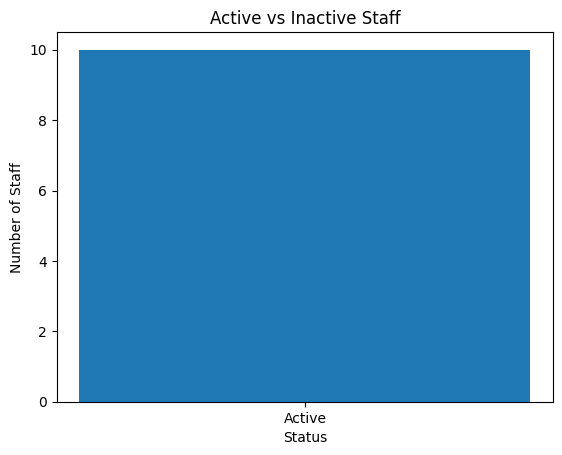

In [197]:
staff_status = staffs.groupBy("active").count()
pdf = staff_status.toPandas()

pdf['active'] = pdf['active'].map({1: 'Active', 0: 'Inactive'})

plt.bar(pdf['active'], pdf['count'])
plt.title("Active vs Inactive Staff")
plt.xlabel("Status")
plt.ylabel("Number of Staff")
plt.show()

<Axes: xlabel='store_id'>

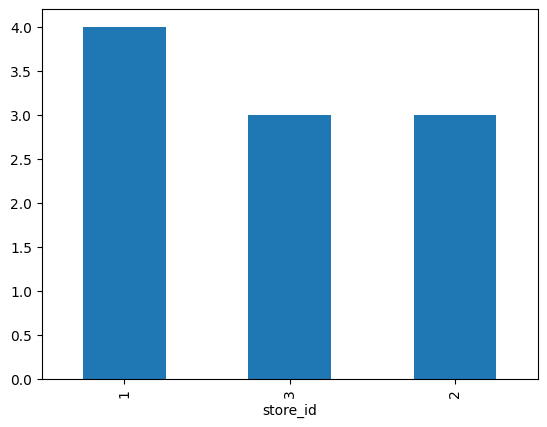

In [198]:
pdf = staffs.toPandas()

pdf['store_id'].value_counts().plot(kind='bar')


## Stocks

In [199]:
stocks    = spark.read.option("header", True).option("inferSchema", True).csv("stocks.csv")


In [200]:
stocks.printSchema()



root
 |-- store_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)



In [201]:
stocks = stocks \
    .withColumn("store_id", fn.col("store_id").cast("int")) \
    .withColumn("product_id", fn.col("product_id").cast("int")) \
    .withColumn("quantity", fn.col("quantity").cast("int"))


In [202]:
stocks.show()

+--------+----------+--------+
|store_id|product_id|quantity|
+--------+----------+--------+
|       1|         1|      27|
|       1|         2|       5|
|       1|         3|       6|
|       1|         4|      23|
|       1|         5|      22|
|       1|         6|       0|
|       1|         7|       8|
|       1|         8|       0|
|       1|         9|      11|
|       1|        10|      15|
|       1|        11|       8|
|       1|        12|      16|
|       1|        13|      13|
|       1|        14|       8|
|       1|        15|       3|
|       1|        16|       4|
|       1|        17|       2|
|       1|        18|      16|
|       1|        19|       4|
|       1|        20|      26|
+--------+----------+--------+
only showing top 20 rows


In [203]:
stocks.select([
    fn.sum(fn.col(c).isNull().cast("int")).alias(c)
    for c in stocks.columns
]).show()


+--------+----------+--------+
|store_id|product_id|quantity|
+--------+----------+--------+
|       0|         0|       0|
+--------+----------+--------+



In [204]:
stocks = stocks.filter(
    fn.col("store_id").isNotNull() &
    fn.col("product_id").isNotNull()
)

In [205]:
stocks = stocks.fillna({
    "quantity": 0
})


In [206]:
stocks = stocks.dropDuplicates()


In [207]:
stocks = stocks.withColumn("quantity", fn.col("quantity").cast("int"))


In [208]:
stocks = stocks.withColumn(
    "stock_level",
    fn.when(fn.col("quantity") == 0, "OUT_OF_STOCK")
    .when(fn.col("quantity") < 10, "LOW")
    .otherwise("SUFFICIENT")
)

In [209]:
print("==================Total stock per store==================")
stocks.groupBy("store_id").sum("quantity").show()


==================Total stock per store==================
+--------+-------------+
|store_id|sum(quantity)|
+--------+-------------+
|       1|         4532|
|       3|         4620|
|       2|         4359|
+--------+-------------+



In [210]:
print("==================Out of stock products==================")
stocks.filter(fn.col("quantity") == 0).count()



==================Out of stock products==================


25

In [211]:
print("==================Stock distribution==================")
stocks.groupBy("stock_level").count().show()



==================Stock distribution==================
+------------+-----+
| stock_level|count|
+------------+-----+
|  SUFFICIENT|  616|
|OUT_OF_STOCK|   25|
|         LOW|  298|
+------------+-----+



# JOINS To enrich data

In [216]:
from pyspark.sql.functions import broadcast

df = orders \
    .join(order_items, "order_id") \
    .join(broadcast(customers), "customer_id") \
    .join(broadcast(products), "product_id") \
    .join(broadcast(categories), "category_id") \
    .join(broadcast(brands), "brand_id") \
    .join(broadcast(stores), "store_id") \
    .join(broadcast(staffs), "staff_id")



In [215]:
df.printSchema()

root
 |-- staff_id: integer (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- brand_id: integer (nullable = true)
 |-- category_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- order_status: integer (nullable = false)
 |-- order_date: date (nullable = true)
 |-- required_date: date (nullable = true)
 |-- shipped_date: date (nullable = true)
 |-- item_id: integer (nullable = true)
 |-- quantity: integer (nullable = false)
 |-- list_price: double (nullable = false)
 |-- discount: double (nullable = false)
 |-- total_price: double (nullable = false)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- phone: string (nullable = false)
 |-- email: string (nullable = false)
 |-- street: string (nullable = false)
 |-- city: string (nullable = false)
 |-- state: string (nullable = false)
 |-- zip_code: string (nullable = false)
 |-- 

In [217]:
df.cache()


DataFrame[staff_id: int, store_id: int, brand_id: int, category_id: int, product_id: int, customer_id: int, order_id: int, order_status: int, order_date: date, required_date: date, shipped_date: date, item_id: int, quantity: int, list_price: double, discount: double, total_price: double, first_name: string, last_name: string, phone: string, email: string, street: string, city: string, state: string, zip_code: string, full_name: string, product_name: string, model_year: int, list_price: double, price_category: string, category_name: string, brand_name: string, store_name: string, phone: string, email: string, street: string, city: string, state: string, zip_code: string, first_name: string, last_name: string, email: string, phone: string, active: int, store_id: int, manager_id: int, full_name: string]

In [218]:
df.explain(True)


== Parsed Logical Plan ==
'Join UsingJoin(Inner, [staff_id])
:- Project [store_id#3570, brand_id#1415, category_id#1416, product_id#4247, customer_id#3568, order_id#3567, order_status#4185, order_date#3564, required_date#3565, shipped_date#3566, staff_id#3571, item_id#4246, quantity#4251, list_price#4252, discount#4253, total_price#4255, first_name#28, last_name#29, phone#1255, email#1256, street#1264, city#1262, state#1263, zip_code#1260, full_name#1261, ... 13 more fields]
:  +- Join Inner, (store_id#3570 = store_id#4713)
:     :- Project [brand_id#1415, category_id#1416, product_id#4247, customer_id#3568, order_id#3567, order_status#4185, order_date#3564, required_date#3565, shipped_date#3566, store_id#3570, staff_id#3571, item_id#4246, quantity#4251, list_price#4252, discount#4253, total_price#4255, first_name#28, last_name#29, phone#1255, email#1256, street#1264, city#1262, state#1263, zip_code#1260, full_name#1261, ... 6 more fields]
:     :  +- Join Inner, (brand_id#1415 = brand

## HBase

In [222]:
!pip install happybase

  Using cached happybase-1.3.0-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached thriftpy2-0.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.5 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
Using cached happybase-1.3.0-py2.py3-none-any.whl (26 kB)
Using cached thriftpy2-0.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (2.1 MB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [happybase]/4 [thriftpy2]


In [223]:
import happybase

connection = happybase.Connection('localhost', port=9090)
connection.open()
print("Connected. Tables:", connection.tables())

Connected. Tables: [b'brands', b'categories', b'customers', b'order_items', b'orders', b'products', b'staffs', b'stocks', b'stores']


In [224]:
def write_to_hbase(table_name, rows_data, connection, batch_size=500):
    table = connection.table(table_name)
    batch = table.batch(batch_size=batch_size)
    count = 0
    for row_key, data in rows_data:
        encoded = {
            k.encode(): str(v).encode()
            for k, v in data.items()
            if v is not None
        }
        batch.put(row_key.encode(), encoded)
        count += 1
    batch.send()
    print(f"✅ Loaded {count} rows into '{table_name}'")

In [225]:
# Customers
rows = customers.collect()
data = [(str(r['customer_id']), {
    'personal:first_name': r['first_name'],
    'personal:last_name':  r['last_name'],
    'personal:full_name':  r['full_name'],
    'personal:email':      r['email'],
    'personal:phone':      r['phone'],
    'location:street':     r['street'],
    'location:city':       r['city'],
    'location:state':      r['state'],
    'location:zip_code':   r['zip_code'],
}) for r in rows]
write_to_hbase('customers', data, connection)

# Orders
rows = orders.collect()
data = [(str(r['order_id']), {
    'info:order_id':       r['order_id'],
    'info:customer_id':    r['customer_id'],
    'info:order_status':   r['order_status'],
    'info:store_id':       r['store_id'],
    'info:staff_id':       r['staff_id'],
    'dates:order_date':    str(r['order_date']),
    'dates:required_date': str(r['required_date']),
    'dates:shipped_date':  str(r['shipped_date']),
}) for r in rows]
write_to_hbase('orders', data, connection)

# Order Items
rows = order_items.collect()
data = [(f"{r['order_id']}_{r['item_id']}", {
    'details:order_id':    r['order_id'],
    'details:item_id':     r['item_id'],
    'details:product_id':  r['product_id'],
    'details:quantity':    r['quantity'],
    'details:list_price':  r['list_price'],
    'details:discount':    r['discount'],
    'details:total_price': r['total_price'],
}) for r in rows]
write_to_hbase('order_items', data, connection)

# Products
rows = products.collect()
data = [(str(r['product_id']), {
    'info:product_name':      r['product_name'],
    'info:brand_id':          r['brand_id'],
    'info:category_id':       r['category_id'],
    'info:model_year':        r['model_year'],
    'pricing:list_price':     r['list_price'],
    'pricing:price_category': r['price_category'],
}) for r in rows]
write_to_hbase('products', data, connection)

# Categories
rows = categories.collect()
data = [(str(r['category_id']), {
    'info:category_name': r['category_name'],
}) for r in rows]
write_to_hbase('categories', data, connection)

# Brands
rows = brands.collect()
data = [(str(r['brand_id']), {
    'info:brand_name': r['brand_name'],
}) for r in rows]
write_to_hbase('brands', data, connection)

# Stores
rows = stores.collect()
data = [(str(r['store_id']), {
    'info:store_name': r['store_name'],
    'info:city':       r['city'],
    'info:state':      r['state'],
    'info:street':     r['street'],
    'info:zip_code':   r['zip_code'],
    'contact:phone':   r['phone'],
    'contact:email':   r['email'],
}) for r in rows]
write_to_hbase('stores', data, connection)

# Staffs
rows = staffs.collect()
data = [(str(r['staff_id']), {
    'personal:first_name': r['first_name'],
    'personal:last_name':  r['last_name'],
    'personal:full_name':  r['full_name'],
    'personal:email':      r['email'],
    'personal:phone':      r['phone'],
    'work:active':         r['active'],
    'work:store_id':       r['store_id'],
    'work:manager_id':     r['manager_id'],
}) for r in rows]
write_to_hbase('staffs', data, connection)

# Stocks
rows = stocks.collect()
data = [(f"{r['store_id']}_{r['product_id']}", {
    'inventory:store_id':    r['store_id'],
    'inventory:product_id':  r['product_id'],
    'inventory:quantity':    r['quantity'],
    'inventory:stock_level': r['stock_level'],
}) for r in rows]
write_to_hbase('stocks', data, connection)

✅ Loaded 1445 rows into 'customers'


✅ Loaded 1615 rows into 'orders'
✅ Loaded 4722 rows into 'order_items'
✅ Loaded 321 rows into 'products'
✅ Loaded 7 rows into 'categories'
✅ Loaded 9 rows into 'brands'
✅ Loaded 3 rows into 'stores'
✅ Loaded 10 rows into 'staffs'
✅ Loaded 939 rows into 'stocks'


In [226]:
print("=" * 50)
print("Verification: Spark vs HBase Row Counts")
print("=" * 50)

checks = {
    'customers':   customers.count(),
    'orders':      orders.count(),
    'order_items': order_items.count(),
    'products':    products.count(),
    'categories':  categories.count(),
    'brands':      brands.count(),
    'stores':      stores.count(),
    'staffs':      staffs.count(),
    'stocks':      stocks.count(),
}

for name, spark_count in checks.items():
    t = connection.table(name)
    hbase_count = sum(1 for _ in t.scan())
    icon = "✅" if hbase_count == spark_count else "❌"
    print(f"  {icon} {name:<15} Spark={spark_count:<6} HBase={hbase_count}")

print("=" * 50)
connection.close()
print("Connection closed. Pipeline complete!")

Verification: Spark vs HBase Row Counts
  ✅ customers       Spark=1445   HBase=1445
  ✅ orders          Spark=1615   HBase=1615
  ✅ order_items     Spark=4722   HBase=4722
  ✅ products        Spark=321    HBase=321
  ✅ categories      Spark=7      HBase=7
  ✅ brands          Spark=9      HBase=9
  ✅ stores          Spark=3      HBase=3
  ✅ staffs          Spark=10     HBase=10
  ✅ stocks          Spark=939    HBase=939
Connection closed. Pipeline complete!
